### Load dataset

In [1]:
import pandas as pd
df_master_sheet = pd.read_csv("MASTER_SHEET.csv")
# df_master_sheet = df_master_sheet.drop(df_master_sheet.columns[65], axis=1)
df_master_sheet.head()

,K,Name,Latin Name,Energy (kcal),Lipids (g),SFA (g),MUFA (g),PUFA (g),Linoleic Acid (g),Trans Fatty Acids (g),...,P NRV,Mg NRV,Fe NRV,Zn NRV,NRF93,Na/K Ratio,Fe/Zn Ratio,Ca/P Ratio,NRFfish (per 100 g),NRFfish (per 100 kcal)
0,0,Forkbeard,Phycis phycis,70,0.1,0.0,0.0,0.0,0.00,0.0,...,32.86%,7.47%,1.43%,5.00%,60.50,0.18,0.40,0.05,1.064905,1.521293
1,0,Atlantic Cod,Gadus morhua,76,0.5,0.1,0.1,0.2,0.00,0.0,...,28.57%,6.93%,2.14%,5.00%,67.22,0.18,0.60,0.08,1.889333,2.485965
2,0,Seabream,Pagellus bogaraveo,102,2.7,0.7,0.8,0.7,0.02,0.0,...,35.71%,10.67%,2.86%,9.00%,75.07,0.30,0.44,0.06,8.298810,8.136088
3,0,Dogfish,Scyliorhinus spp.,82,0.2,0.0,0.0,0.1,0.00,0.0,...,27.14%,8.53%,0.71%,3.00%,61.71,0.59,0.33,0.07,7.224202,8.810003
4,0,Bream,"Beryx decadactylus, Alfonsino",80,0.7,0.1,0.1,0.2,0.00,0.0,...,27.14%,7.47%,5.71%,8.00%,82.32,0.19,1.00,0.16,3.520917,4.401146


In [2]:
print('Number of NaNs in dataset (should be 0): ')
df_master_sheet.isna().sum().sum()

Number of NaNs in dataset (should be 0): 


np.int64(0)

# === LIST OF PLOTS TO MAKE ===

### ===== Macronutrients and Fatty Acids ===== 
##### EPA + DHA bar chart — stacked or side-by-side bars with muted light colors; compared to Daily Value.
##### SFA/MUFA/PUFA horizontal stacked bar chart
##### Radial chart of fatty acids ratios (top 10 or top 15)
##### Macronutrietn contributions fro energy stacked bar chart (protein and fat)

### ===== Mineral Ratios =====
##### Na vs K scatterplot — includes red “Na = K (Na/K = 1)” reference line; upper half red (unfavorable), lower half green (favorable).
##### Ca / P scatterplot — same visual concept adapted for bone-health ratio.
##### Fe / Zn scatterplot — both zones red due to opposite deficiency/toxicity implications; customized gray shading tested.

### ===== Boxplots =====
##### kCal
##### NRV93
##### protein
##### niancin

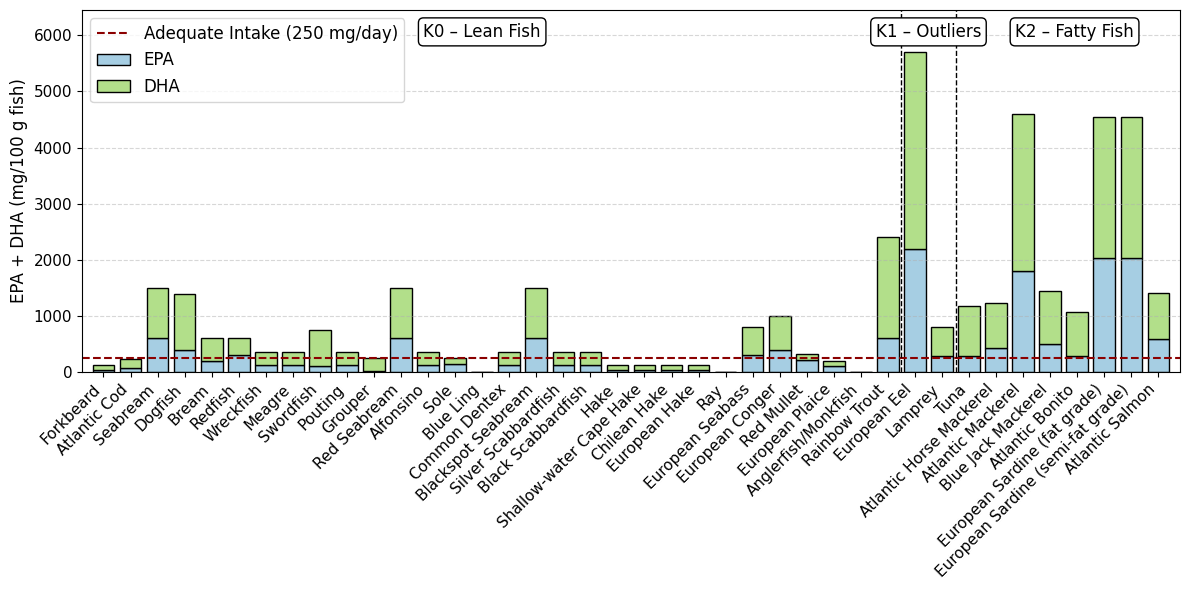

In [78]:
import matplotlib.pyplot as plt

# Convert EPA and DHA to mg (values are in g)
df_master_sheet["EPA (mg)"] = df_master_sheet["EPA (g)"] * 1000
df_master_sheet["DHA (mg)"] = df_master_sheet["DHA (g)"] * 1000

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars for EPA + DHA
ax.bar(df_master_sheet["Name"], df_master_sheet["EPA (mg)"], label="EPA", color="#a6cee3", edgecolor="black")
ax.bar(df_master_sheet["Name"], df_master_sheet["DHA (mg)"], bottom=df_master_sheet["EPA (mg)"], label="DHA", color="#b2df8a", edgecolor = "black")

# Add DV reference line at 250 mg
ax.axhline(250, color="darkred", linestyle="--", linewidth=1.5, label="Adequate Intake (250 mg/day)")

# Example: place three text boxes above the bars
ax.text(14, 5900, "K0 – Lean Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(30.5, 5900, "K1 – Outliers",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(35.9, 5900, "K2 – Fatty Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Formatting
ax.set_ylabel("EPA + DHA (mg/100 g fish)", fontsize = 12)
ax.legend(fontsize = 12)
ax.margins(x=0.01)
plt.xticks(rotation=45, ha="right", fontsize = 11)
plt.yticks(fontsize = 11)
ax.axvline(x=29.497, color="black", linestyle="--", lw=1)
ax.axvline(x=31.5, color="black", linestyle="--", lw=1)
plt.ylim(0, 6450)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
plt.tight_layout()
#plt.savefig('EPA_DHA_AI_StackedBarChart.png', dpi = 300)
plt.show()

In [54]:
# SFA/MUFA/PUFA horizontal stacked bar chart

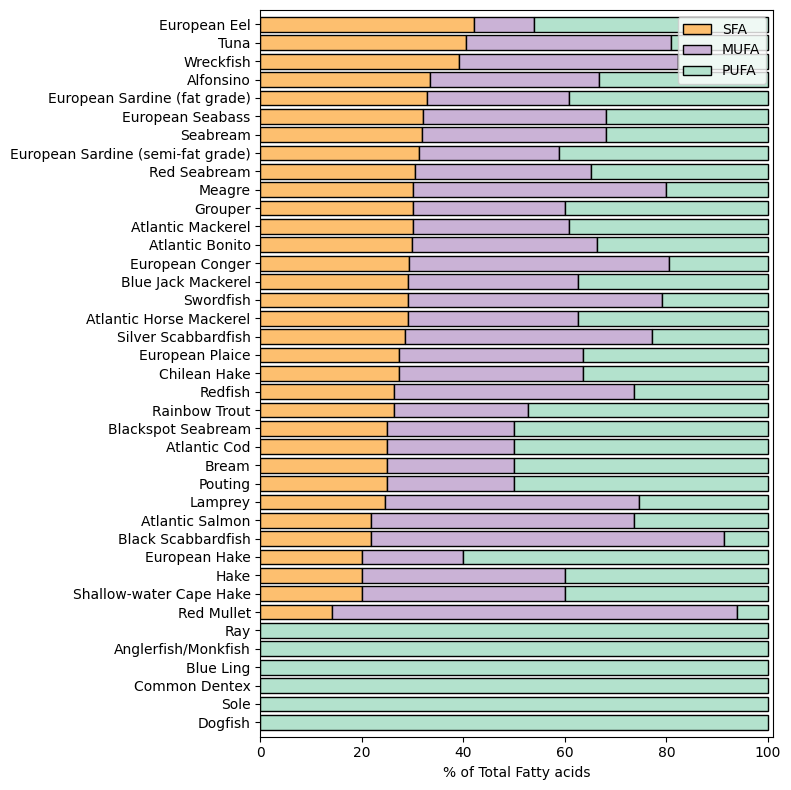

In [100]:
df_norm = df_master_sheet
df_norm[["SFA (g)","MUFA (g)","PUFA  (g)"]] = df_master_sheet[["SFA (g)","MUFA (g)","PUFA  (g)"]].div(df_master_sheet[["SFA (g)","MUFA (g)","PUFA  (g)"]].sum(axis=1), axis=0) * 100
df_norm["Name"] = df_norm["Name"].astype(str)
df_norm = df_norm.sort_values("SFA (g)", ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(8,8))

# Plot stacked horizontal bars
ax.barh(df_norm["Name"], df_norm["SFA (g)"], label="SFA", color="#fdbf6f", edgecolor="black")
ax.barh(df_norm["Name"], df_norm["MUFA (g)"], left=df_norm["SFA (g)"], label="MUFA", color="#cab2d6", edgecolor="black")
ax.barh(df_norm["Name"], df_norm["PUFA  (g)"], left=df_norm["SFA (g)"]+df_norm["MUFA (g)"], label="PUFA", color="#b3e2cd", edgecolor="black")

# Labels and legend
ax.set_xlabel("% of Total Fatty acids", fontsize=10)
ax.legend(frameon=True, loc = 'upper right')
plt.margins(x=0.01, y=0.01)
plt.tight_layout()
# plt.savefig("fatty_acid_cathegory_perc_colors.png", dpi=300, bbox_inches="tight")
plt.show()

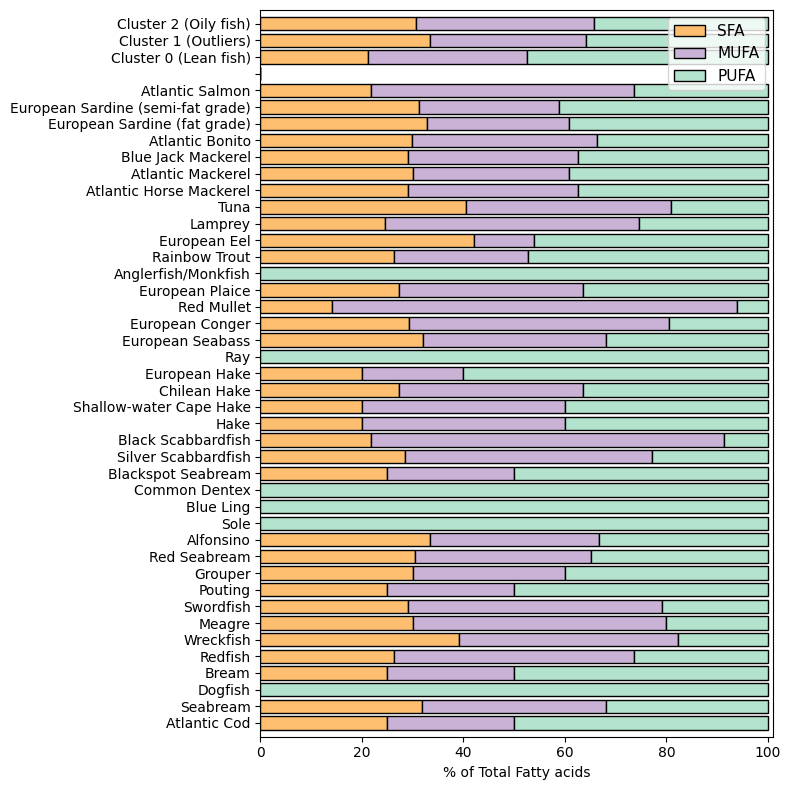

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy and normalize fatty acids
df_c = df_master_sheet.copy()
cols = ["SFA (g)", "MUFA (g)", "PUFA  (g)"]
df_c[cols] = df_c[cols].div(df_c[cols].sum(axis=1), axis=0) * 100
df_c["Name"] = df_c["Name"].astype(str)

# Compute cluster averages from 'K' column
cluster_means = (
    df_c.groupby("K")[cols]
    .mean()
    .reset_index()
    .rename(columns={"K": "Cluster"})
)
# Custom names for clusters
cluster_labels = {
    0: "Cluster 0 (Lean fish)",
    1: "Cluster 1 (Outliers)",
    2: "Cluster 2 (Oily fish)"
}

cluster_means["Name"] = cluster_means["Cluster"].map(cluster_labels)

# Append averages to df_norm
df_c = pd.concat([df_c, cluster_means[["Name"] + cols]], ignore_index=True)

# Optional: add an empty row after existing data
gap_row = pd.DataFrame([{"Name": "", "SFA (g)": 0, "MUFA (g)": 0, "PUFA  (g)": 0}])
df_c = pd.concat([df_c.iloc[:40], gap_row, df_c.iloc[40:]]).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(8,8))
ax.barh(df_c["Name"], df_norm["SFA (g)"], label="SFA", color="#fdbf6f", edgecolor="black")
ax.barh(df_c["Name"], df_norm["MUFA (g)"], left=df_norm["SFA (g)"], label="MUFA", color="#cab2d6", edgecolor="black")
ax.barh(df_c["Name"], df_norm["PUFA  (g)"], left=df_norm["SFA (g)"] + df_norm["MUFA (g)"], label="PUFA", color="#b3e2cd", edgecolor="black")

ax.set_xlabel("% of Total Fatty acids", fontsize=10)
ax.legend(frameon=True, loc='upper right', fontsize = 11)
plt.margins(x=0.01, y=0.01)
plt.tight_layout()
#plt.savefig("NEW_SFA_MUFA_PUFA_comp_StackedBarChart.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
#Macronutrietn contributions for energy stacked bar chart (protein and fat)

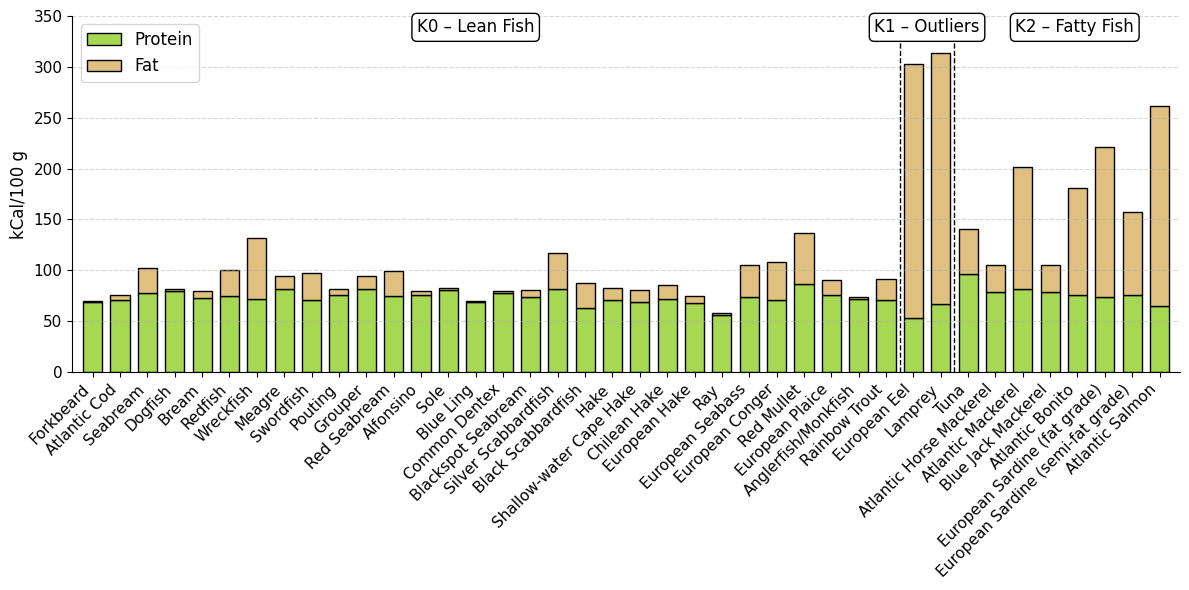

In [97]:
import numpy as np

# --- Create figure ---
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars
ax.bar(df_master_sheet["Name"], df_master_sheet["Energy from Protein [kcal]"], 
       label="Protein", color="#a6d854", edgecolor = "black", width = 0.7)
ax.bar(df_master_sheet["Name"], df_master_sheet["Energy from Lipids (kcal)"], 
       bottom=df_master_sheet["Energy from Protein [kcal]"], label="Fat", color="#e0c080", edgecolor="black", width = 0.7)


# Titles and labels
ax.set_ylabel("kCal/100 g", fontsize=12)
ax.legend(frameon=True, loc = "upper left", fontsize = 12)

# Example: place three text boxes above the bars
ax.text(14, 330, "K0 – Lean Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(30.5, 330, "K1 – Outliers",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(35.9, 330, "K2 – Fatty Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Clean x-axis
plt.xticks(rotation=45, ha = 'right', fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
# Example vertical lines after species 15 and 30
ax.axvline(x=29.5, color="black", linestyle="--", lw=1)
ax.axvline(x=31.5, color="black", linestyle="--", lw=1)
plt.ylim(0, 350)
plt.yticks(fontsize = 11)
plt.tight_layout()
plt.margins(x=0.01)

# Save high-res (optional)
#plt.savefig("NEW_macronutrient_contributions_kcal_StackedBarChart.png", dpi=300, bbox_inches="tight")

plt.show()

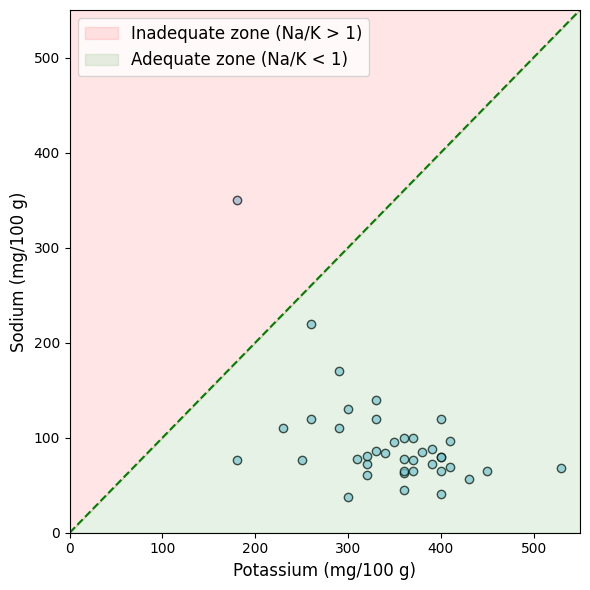

In [102]:
df_minerals = df_master_sheet.copy()

fig, ax = plt.subplots(figsize=(6,6))

# Scatter
ax.scatter(
    df_minerals["Potassium (mg)"], 
    df_minerals["Sodium (mg)"], 
    alpha=0.7, edgecolors="k", facecolors="skyblue"
)

# Limits
max_val = 550
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

# Shaded regions
ax.fill_between(
    [0, max_val], [0, max_val], max_val, 
    color="red", alpha=0.1, label="Inadequate zone (Na/K > 1)"
)
ax.fill_between(
    [0, max_val], 0, [0, max_val], 
    color="green", alpha=0.1, label="Adequate zone (Na/K < 1)"
)

ax.plot([0,550], [0,550], 'g--')

ax.set_xlabel("Potassium (mg/100 g)", fontsize = 12)
ax.set_ylabel("Sodium (mg/100 g)", fontsize = 12)
plt.ylim(0, 550)
plt.xlim(0, 550)
ax.legend(fontsize = 12)
plt.tight_layout()
#plt.savefig("Na_K_Mineral_Ratio_ScatterPlot.png", dpi = 300)
plt.show()

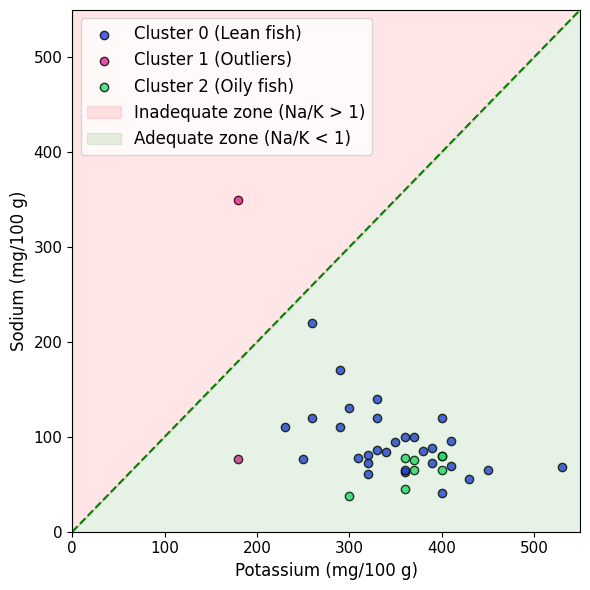

In [128]:
import matplotlib.pyplot as plt

df_minerals = df_master_sheet.copy()

# Color map by cluster K
cluster_colors = {0: "#273be2", 1: "#e22798", 2: "#27e271"}
df_minerals["color"] = df_minerals["K"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(6,6))

cluster_labels = {
    0: "Cluster 0 (Lean fish)",
    1: "Cluster 1 (Outliers)",
    2: "Cluster 2 (Oily fish)"
}

# Scatter, colored by cluster
for k, group in df_minerals.groupby("K"):
    ax.scatter(
        group["Potassium (mg)"],
        group["Sodium (mg)"],
        alpha=0.8,
        edgecolors="k",
        facecolors=cluster_colors[k],
        label= cluster_labels[k]
    )

# Axes limits
max_val = 550
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

# Shaded zones
ax.fill_between(
    [0, max_val], [0, max_val], max_val, 
    color="red", alpha=0.1, label="Inadequate zone (Na/K > 1)"
)
ax.fill_between(
    [0, max_val], 0, [0, max_val], 
    color="green", alpha=0.1, label="Adequate zone (Na/K < 1)"
)


# Diagonal
ax.plot([0, max_val], [0, max_val], 'g--')

# Labels
ax.set_xlabel("Potassium (mg/100 g)", fontsize = 12)
ax.set_ylabel("Sodium (mg/100 g)", fontsize = 12)
plt.yticks(fontsize = 11)
plt.xticks(fontsize = 11)
plt.ylim(0, 550)
plt.xlim(0, 550)
ax.legend(fontsize = 12)
plt.tight_layout()
#plt.savefig("NEW_Na_K_Mineral_Ratio_ScatterPlot.png", dpi = 300)
plt.show()

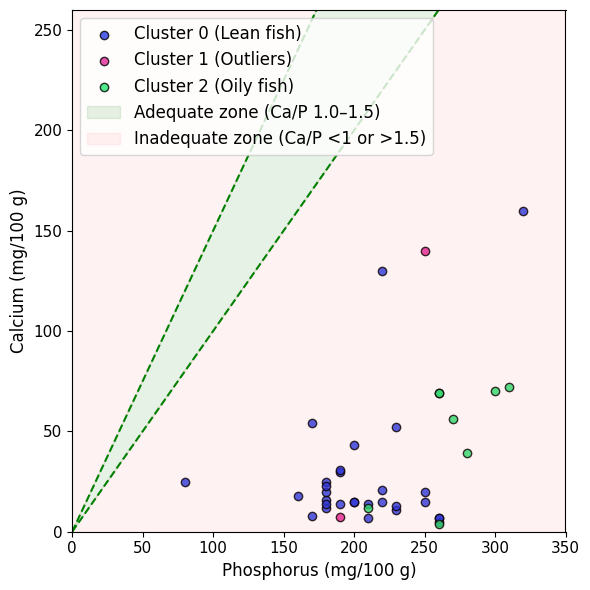

In [130]:
# Color map by cluster K
cluster_colors = {0: "#273be2", 1: "#e22798", 2: "#27e271"}
df_minerals["color"] = df_minerals["K"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(6,6))

cluster_labels = {
    0: "Cluster 0 (Lean fish)",
    1: "Cluster 1 (Outliers)",
    2: "Cluster 2 (Oily fish)"
}

# Scatter, colored by cluster
for k, group in df_minerals.groupby("K"):
    ax.scatter(
        group["Phosphorus (mg)"],
        group["Calcium (mg)"],
        alpha=0.8,
        edgecolors="k",
        facecolors=cluster_colors[k],
        label= cluster_labels[k]
    )

# Limits
max_val = 350
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

# Reference lines for Ca/P = 1.0 and 1.5
x_vals = [0, max_val]
ax.plot(x_vals, x_vals, 'g--')
ax.plot(x_vals, [1.5*x for x in x_vals], 'g--')

# Shade adequate band (1.0–1.5)
ax.fill_between(x_vals, [x for x in x_vals], [1.5*x for x in x_vals], 
                color="green", alpha=0.1, label="Adequate zone (Ca/P 1.0–1.5)")

# Red zones (below 1.0 and above 1.5)
ax.fill_between(x_vals, 0, [x for x in x_vals], 
                color="red", alpha=0.05, label="Inadequate zone (Ca/P <1 or >1.5)")
ax.fill_between(x_vals, [1.5*x for x in x_vals], max_val, 
                color="red", alpha=0.05)

ax.set_xlabel("Phosphorus (mg/100 g)", fontsize = 12)
ax.set_ylabel("Calcium (mg/100 g)", fontsize = 12)
ax.legend(fontsize = 12, loc = "upper left")
plt.yticks(fontsize = 11)
plt.xticks(fontsize = 11)
plt.ylim(0, 260)
plt.tight_layout()
#plt.savefig("NEW_Ca_P_Mineral_Ratio_ScatterPlot.png", dpi = 300)
plt.show()

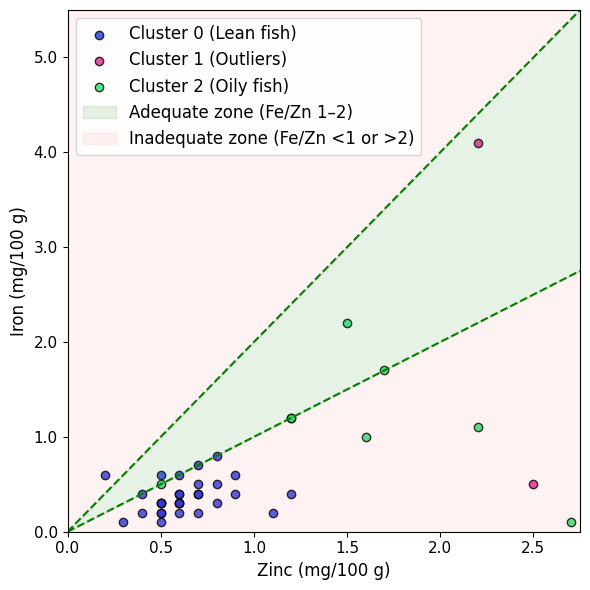

In [134]:
# Color map by cluster K
cluster_colors = {0: "#273be2", 1: "#e22798", 2: "#27e271"}
df_minerals["color"] = df_minerals["K"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(6,6))

cluster_labels = {
    0: "Cluster 0 (Lean fish)",
    1: "Cluster 1 (Outliers)",
    2: "Cluster 2 (Oily fish)"
}

# Scatter, colored by cluster
for k, group in df_minerals.groupby("K"):
    ax.scatter(
        group["Zinc (mg)"],
        group["Iron (mg)"],
        alpha=0.8,
        edgecolors="k",
        facecolors=cluster_colors[k],
        label= cluster_labels[k]
    )

# Limits
max_val = 5.5
ax.set_xlim(0, max_val/2)
ax.set_ylim(0, max_val)

# Reference lines Fe/Zn = 1 and Fe/Zn = 2
x_vals = [0, max_val/2]
ax.plot(x_vals, [x for x in x_vals], 'g--')
ax.plot(x_vals, [2*x for x in x_vals], 'g--')

# Green adequate band (Fe/Zn 1–2)
ax.fill_between(x_vals, [x for x in x_vals], [2*x for x in x_vals], 
                color="green", alpha=0.1, label="Adequate zone (Fe/Zn 1–2)")

# Red zones
ax.fill_between(x_vals, 0, [x for x in x_vals], 
                color="red", alpha=0.05, label="Inadequate zone (Fe/Zn <1 or >2)")
ax.fill_between(x_vals, [2*x for x in x_vals], max_val, 
                color="red", alpha=0.05)

# Labels
ax.set_xlabel("Zinc (mg/100 g)", fontsize = 12)
ax.set_ylabel("Iron (mg/100 g)", fontsize = 12)
ax.legend(fontsize = 12)
plt.yticks(fontsize = 11)
ax.yaxis.set_major_formatter("{:.1f}".format)
plt.xticks(fontsize = 11)
plt.tight_layout()
#plt.savefig("NEW_Fe_Zn_Mineral_Ratio_ScatterPlot.png", dpi = 300)
plt.show()

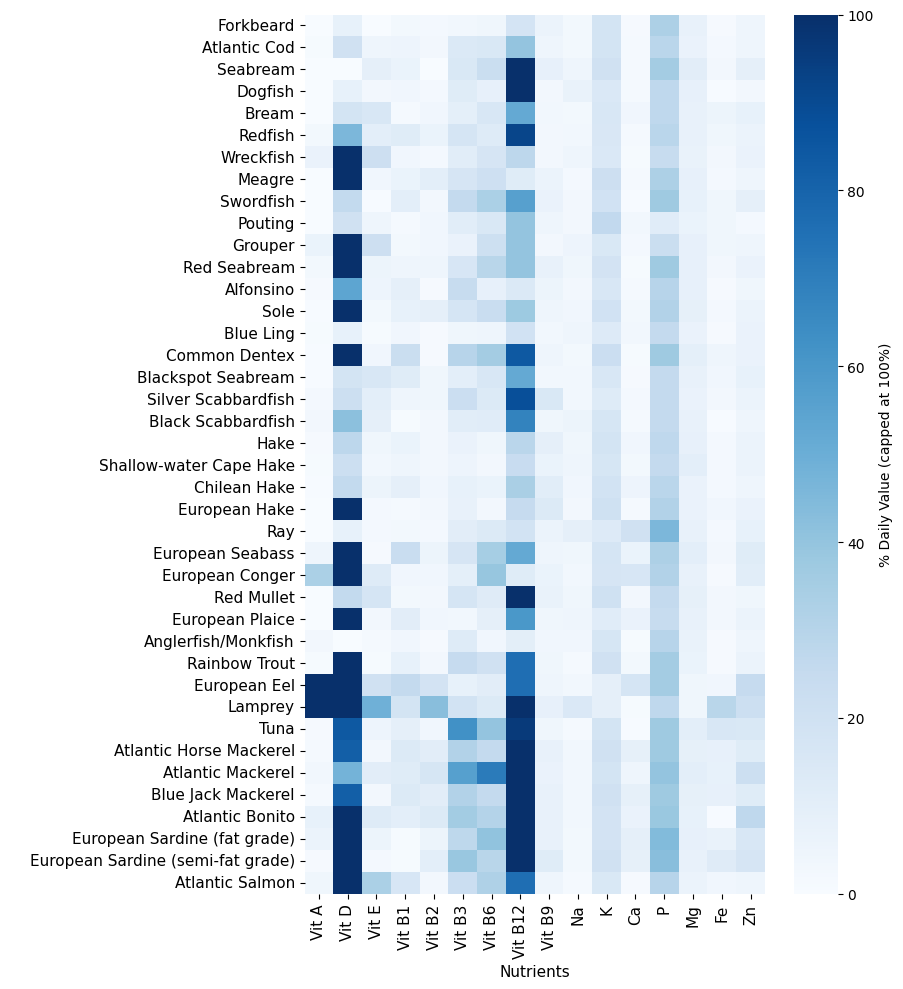

In [166]:
import seaborn as sns

# Load CSV
df = df_master_sheet.copy()

# Select only Name and DV columns
dv_cols = [c for c in df.columns if "NRV" in c]
df_dv = df[["Name"] + dv_cols].copy()


# Clean % symbols and convert to float
for col in dv_cols:
    df_dv[col] = df_dv[col].str.replace("%", "", regex=False).astype(float)


# Cap values at 100%
df_dv[dv_cols] = df_dv[dv_cols].clip(upper=100)

# Set index as fish name
df_dv = df_dv.set_index("Name")
df_dv = df_dv.rename(columns=lambda x: x.replace(" NRV", ""))

# Plot heatmap
plt.figure(figsize=(9, 10))
sns.heatmap(df_dv, cmap="Blues", annot=False, cbar_kws={'label': '% Daily Value (capped at 100%)'})
plt.xlabel("Nutrients", fontsize = 11)
plt.ylabel(" ")
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

#plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("NEW_Vit_Minerals_heatmap.png", dpi = 300)
plt.show()

## BOXPLOTS

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\3840523212.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="NRF93", data=df_nrf, palette="Set2", showfliers=False)


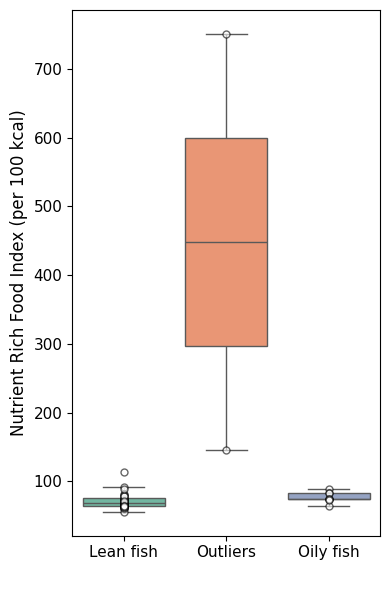

In [170]:

df_nrf = df_master_sheet.copy()

# Map category codes to names
category_map = {
    0: "Lean fish",
    1: "Outliers",
    2: "Oily fish"
}

df_nrf["K"] = df_nrf["K"].map(category_map)

# Boxplot of NRF9.3 by category
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="NRF93", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="NRF93", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Nutrient Rich Food Index (per 100 kcal)", fontsize = 12)
plt.tight_layout()
#plt.savefig("NRF93_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\887798291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Energy (kcal)", data=df_nrf, palette="Set2", showfliers=False)


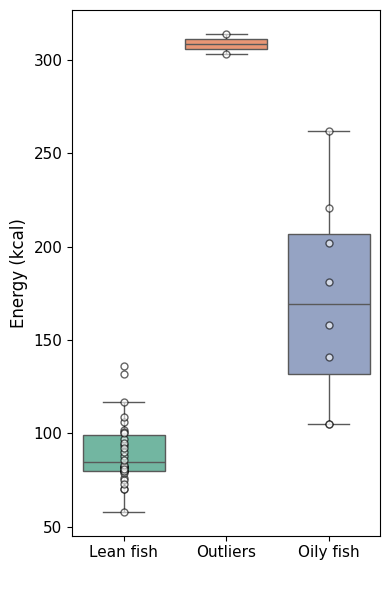

In [171]:
# Boxplot of NRF9.3 by category
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Energy (kcal)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Energy (kcal)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Energy (kcal)", fontsize = 12)
plt.tight_layout()
#plt.savefig("kcal_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\3375611058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Lipids (g)", data=df_nrf, palette="Set2", showfliers=False)


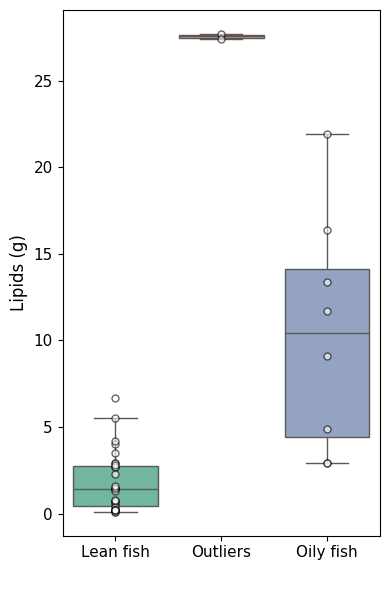

In [174]:
# Boxplot of NRF9.3 by category
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Lipids (g)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Lipids (g)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Lipids (g)", fontsize = 12)
plt.tight_layout()
#plt.savefig("lipids_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\2646695840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="SFA (g)", data=df_nrf, palette="Set2", showfliers=False)


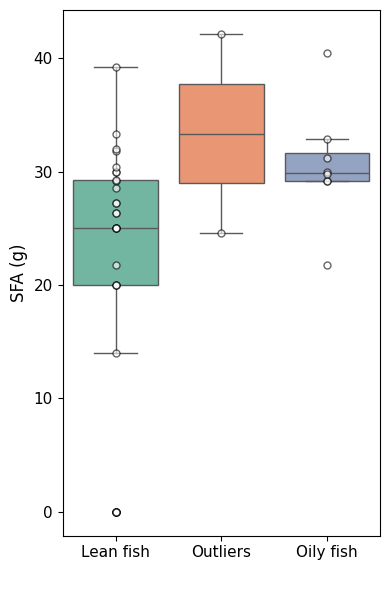

In [176]:
# Boxplot of NRF9.3 by category
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="SFA (g)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="SFA (g)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("SFA (g)", fontsize = 12)
plt.tight_layout()
#plt.savefig("SFA_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\1167803295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="MUFA (g)", data=df_nrf, palette="Set2", showfliers=False)


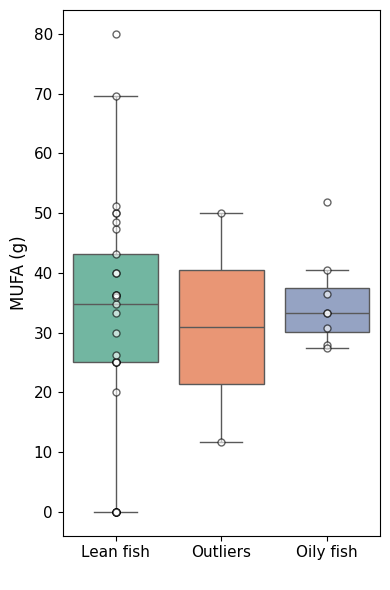

In [178]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="MUFA (g)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="MUFA (g)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("MUFA (g)", fontsize = 12)
plt.tight_layout()
#plt.savefig("MUFA_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\2964806151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="PUFA  (g)", data=df_nrf, palette="Set2", showfliers=False)


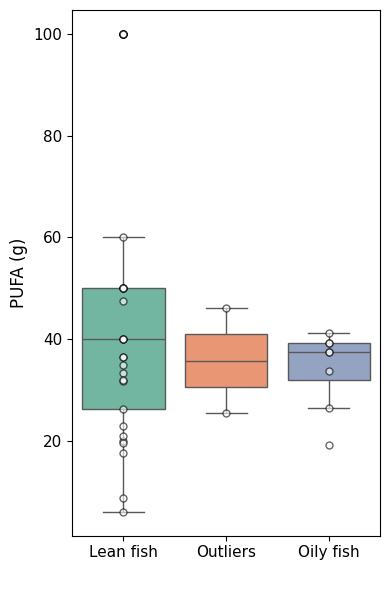

In [181]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="PUFA  (g)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="PUFA  (g)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("PUFA (g)", fontsize = 12)
plt.tight_layout()
#plt.savefig("PUFA_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\1030457270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Riboflavin (mg)", data=df_nrf, palette="Set2", showfliers=False)


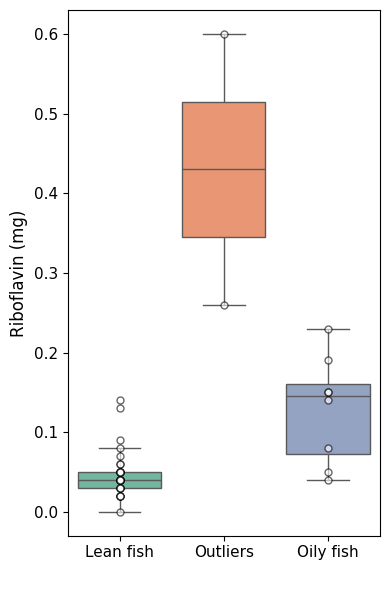

In [183]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Riboflavin (mg)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Riboflavin (mg)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Riboflavin (mg)", fontsize = 12)
plt.tight_layout()
#plt.savefig("riboflavin_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\838614580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Niacin (Vitamin B3) (mg)", data=df_nrf, palette="Set2", showfliers=False)


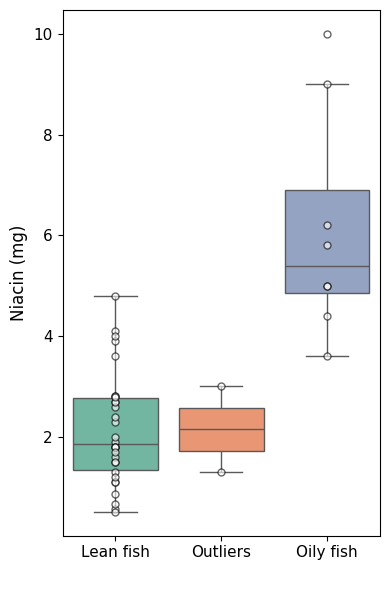

In [185]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Niacin (Vitamin B3) (mg)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Niacin (Vitamin B3) (mg)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Niacin (mg)", fontsize = 12)
plt.tight_layout()
# plt.savefig("niancin_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\645609622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Vitamin B6 (mg)", data=df_nrf, palette="Set2", showfliers=False)


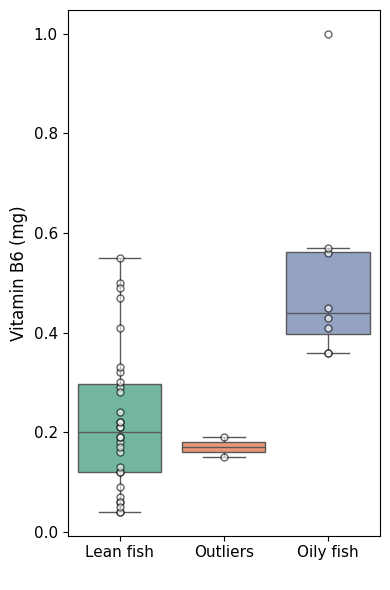

In [187]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Vitamin B6 (mg)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Vitamin B6 (mg)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Vitamin B6 (mg)", fontsize = 12)
plt.tight_layout()
# plt.savefig("vitB6_BoxPlot.png", dpi = 300)
plt.show()

C:\Users\Oli\AppData\Local\Temp\ipykernel_4256\2883801008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="K", y="Vitamin B12 (µg)", data=df_nrf, palette="Set2", showfliers=False)


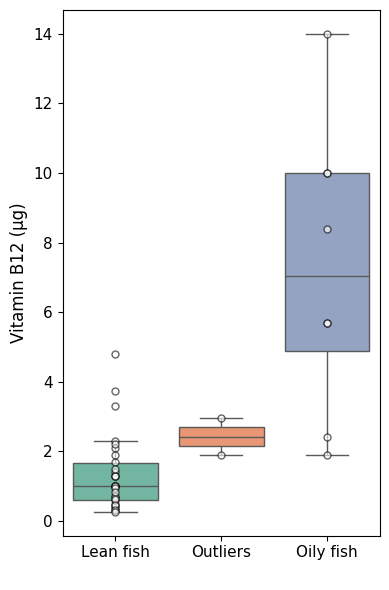

In [191]:
plt.figure(figsize=(4,6))
sns.boxplot(x="K", y="Vitamin B12 (µg)", data=df_nrf, palette="Set2", showfliers=False)
sns.stripplot(x="K", y="Vitamin B12 (µg)", data=df_nrf, color="white", alpha=0.6, jitter=False, edgecolor="Black", linewidth=1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.xlabel(" ")
plt.ylabel("Vitamin B12 (μg)", fontsize = 12)
plt.tight_layout()
#plt.savefig("vitB12_BoxPlot.png", dpi = 300)
plt.show()

In [193]:
# Copy data
df_fattyacids = df_master_sheet.copy()

# Sort descending (largest on top)
df_fattyacids = df_fattyacids.sort_values(["PUFA/SFA index "], ascending=False)

# Show top 20
print(df_fattyacids[["Name", "PUFA/SFA index "]].head(20))


                                 Name  PUFA/SFA index 
22                      European Hake             3.00
1                        Atlantic Cod             2.00
9                             Pouting             2.00
4                               Bream             2.00
20            Shallow-water Cape Hake             2.00
16                 Blackspot Seabream             2.00
19                               Hake             2.00
29                      Rainbow Trout             1.80
27                    European Plaice             1.33
10                            Grouper             1.33
21                       Chilean Hake             1.33
38  European Sardine (semi-fat grade)             1.32
34                  Atlantic Mackerel             1.31
33            Atlantic Horse Mackerel             1.29
35                 Blue Jack Mackerel             1.29
39                    Atlantic Salmon             1.21
37       European Sardine (fat grade)             1.19
11        

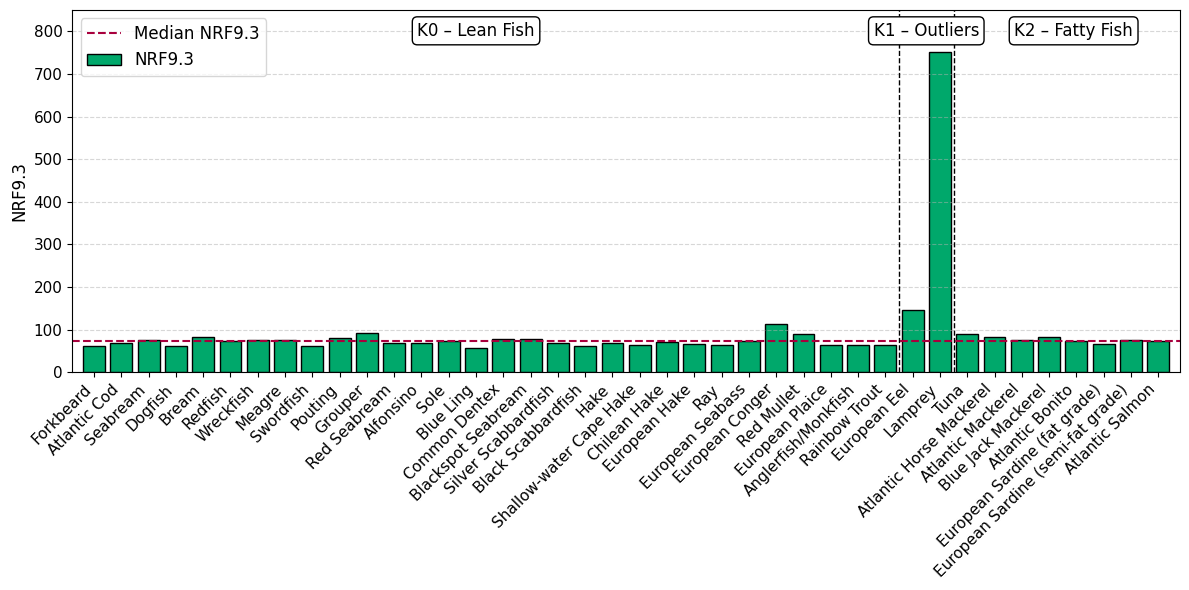

In [36]:
import matplotlib.pyplot as plt

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars for EPA + DHA
ax.bar(df_master_sheet["Name"], df_master_sheet["NRF93"], label="NRF9.3", color="#00A86B", edgecolor="black")

# Add DV reference line at 250 mg
ax.axhline(73.06, color="#A8003D", linestyle="--", linewidth=1.5, label="Median NRF9.3")

# Example: place three text boxes above the bars
ax.text(14, 780, "K0 – Lean Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(30.5, 780, "K1 – Outliers",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(35.9, 780, "K2 – Fatty Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Formatting
ax.set_ylabel("NRF9.3", fontsize = 12)
ax.legend(fontsize = 12)
ax.margins(x=0.01)
plt.xticks(rotation=45, ha="right", fontsize = 11)
plt.yticks(fontsize = 11)
ax.axvline(x=29.497, color="black", linestyle="--", lw=1)
ax.axvline(x=31.5, color="black", linestyle="--", lw=1)
plt.ylim(0, 850)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
plt.tight_layout()
# plt.savefig('NRF93_BarChart.png', dpi = 300)
plt.show()

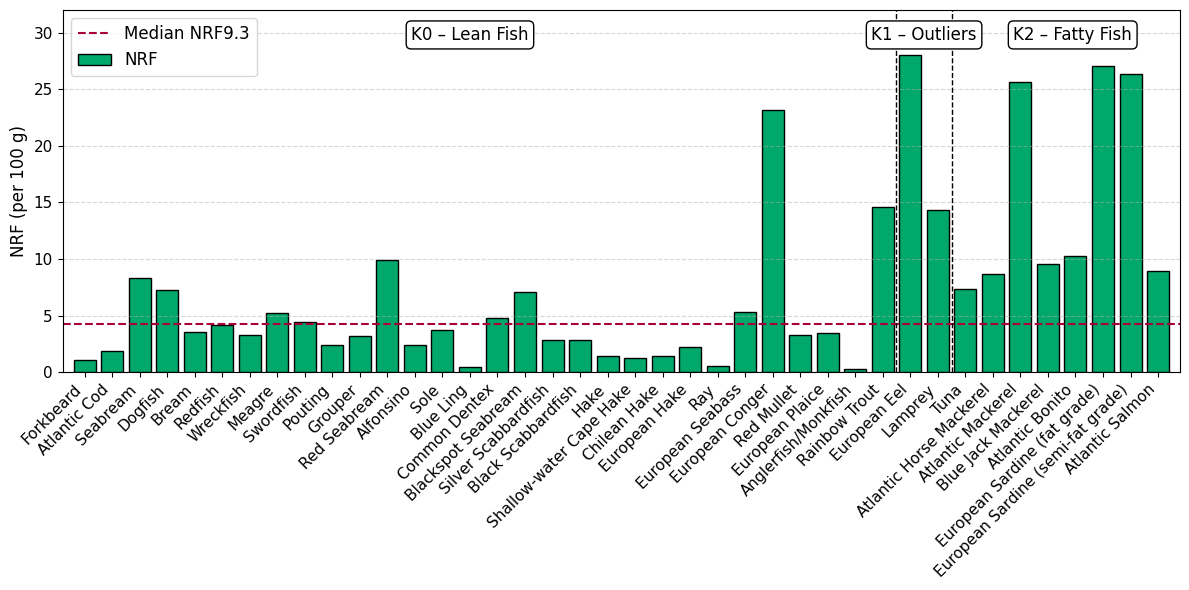

In [18]:
import matplotlib.pyplot as plt

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars for EPA + DHA
ax.bar(df_master_sheet["Name"], df_master_sheet["NRFfish (per 100 g)"], label="NRF", color="#00A86B", edgecolor="black")

# Add DV reference line at 250 mg
ax.axhline(4.27, color="#A8003D", linestyle="--", linewidth=1.5, label="Median NRF9.3")

# Example: place three text boxes above the bars
ax.text(14, 29, "K0 – Lean Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(30.5, 29, "K1 – Outliers",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(35.9, 29, "K2 – Fatty Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Formatting
ax.set_ylabel("NRF (per 100 g)", fontsize = 12)
ax.legend(fontsize = 12)
ax.margins(x=0.01)
plt.xticks(rotation=45, ha="right", fontsize = 11)
plt.yticks(fontsize = 11)
ax.axvline(x=29.497, color="black", linestyle="--", lw=1)
ax.axvline(x=31.5, color="black", linestyle="--", lw=1)
plt.ylim(0, 32)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
plt.tight_layout()
/plt.savefig('NRFfish_per100g_BarChart.png', dpi = 300)
plt.show()

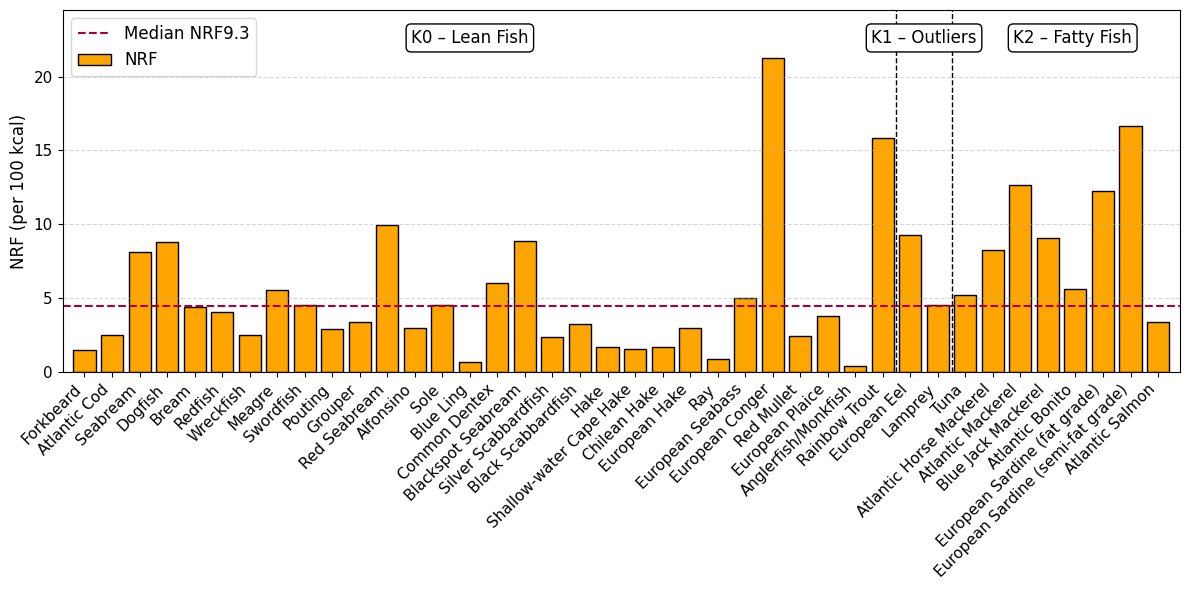

In [23]:
import matplotlib.pyplot as plt

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars for EPA + DHA
ax.bar(df_master_sheet["Name"], df_master_sheet["NRFfish (per 100 kcal)"], label="NRF", color="orange", edgecolor="black")

# Add DV reference line at 250 mg
ax.axhline(4.47, color="#A8003D", linestyle="--", linewidth=1.5, label="Median NRF9.3")

# Example: place three text boxes above the bars
ax.text(14, 22, "K0 – Lean Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(30.5, 22, "K1 – Outliers",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

ax.text(35.9, 22, "K2 – Fatty Fish",
        ha="center", va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Formatting
ax.set_ylabel("NRF (per 100 kcal)", fontsize = 12)
ax.legend(fontsize = 12)
ax.margins(x=0.01)
plt.xticks(rotation=45, ha="right", fontsize = 11)
plt.yticks(fontsize = 11)
ax.axvline(x=29.497, color="black", linestyle="--", lw=1)
ax.axvline(x=31.5, color="black", linestyle="--", lw=1)
plt.ylim(0, 24.5)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
plt.tight_layout()
# plt.savefig('NRFfish_perkcal_BarChart.png', dpi = 300)
plt.show()